In [15]:
import pandas as pd

df = pd.read_csv("../data/raw/car_data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [16]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [17]:
df["Car_Age"] = 2026 - df["Year"]
df.drop(["Year", "Car_Name"], axis=1, inplace=True)

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ["Fuel_Type", "Seller_Type", "Transmission"]:
    df[col] = le.fit_transform(df[col])

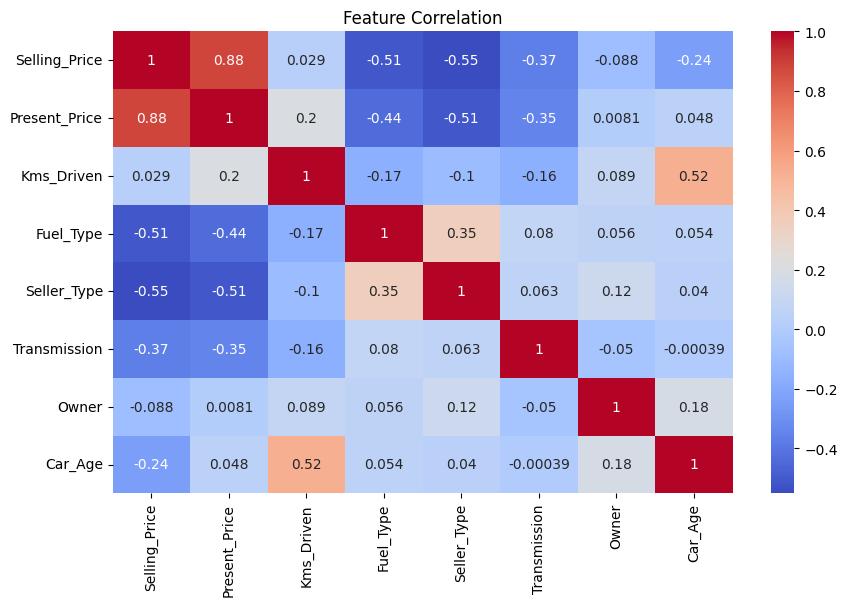

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

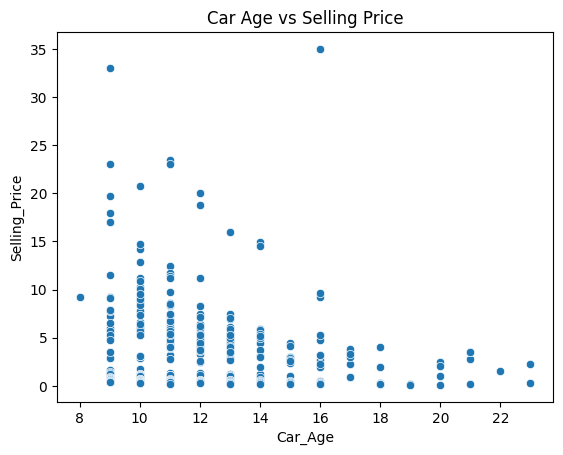

In [20]:
sns.scatterplot(x="Car_Age", y="Selling_Price", data=df)
plt.title("Car Age vs Selling Price")
plt.show()

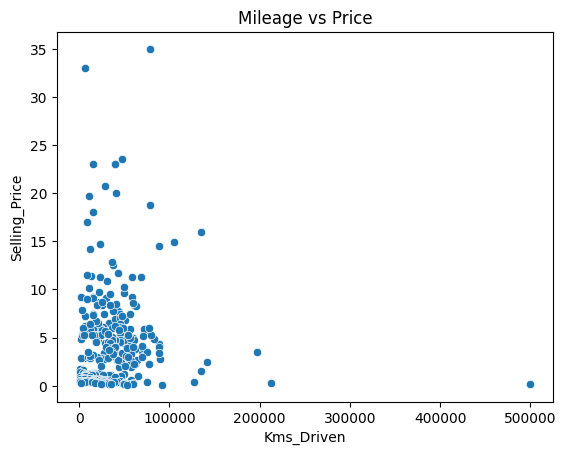

In [21]:
sns.scatterplot(x="Kms_Driven", y="Selling_Price", data=df)
plt.title("Mileage vs Price")
plt.show()

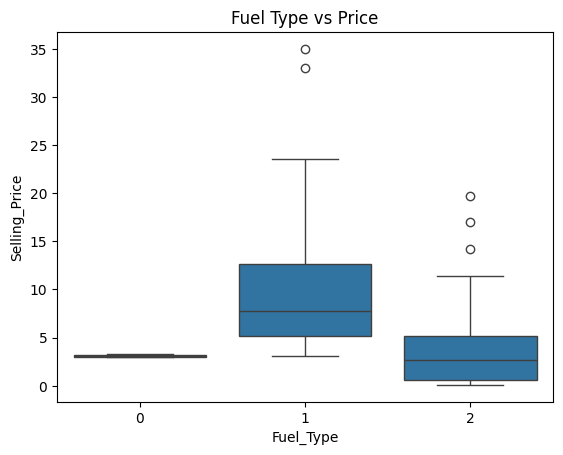

In [22]:
sns.boxplot(x="Fuel_Type", y="Selling_Price", data=df)
plt.title("Fuel Type vs Price")
plt.show()

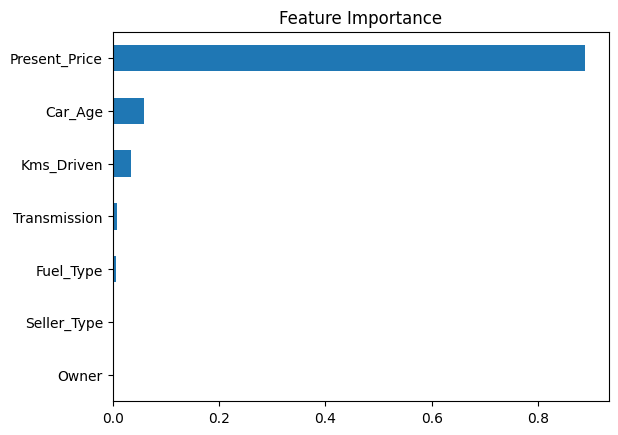

In [23]:
import joblib

model = joblib.load("../models/model.pkl")

import pandas as pd
feature_importance = pd.Series(model.feature_importances_, index=df.drop("Selling_Price", axis=1).columns)

feature_importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()